# ACCESS-rOM3 MC 4km Pan-Antarctic with Ice-Shelves Scaling

End-to-end pipeline generating scaling plots for the [ACCESS-rOM3 MC 4km Pan-Antarctic configuration with Ice-Shelves](https://github.com/claireyung/access-om3-configs/tree/access-rom3-panan4km-iceshelf).

In [1]:
%load_ext autoreload
%autoreload 2

# Record package versions for future reference
from importlib.metadata import version
for pkg in ("access.config.utils", "access.profiling", "payu", "experiment_generator", "experiment_runner"):
    print(f"{pkg}: {version(pkg)}")

access.config.utils: 0.5.dev3+g45c8354dc
access.profiling: 0.2.dev39+g4e244fb8b
payu: 1.3.6
experiment_generator: 0.10.3.dev1+g93564c8e5
experiment_runner: 0.3.2


## Setup
The following variables control where the configurations and model run outputs are saved.

In [2]:
## Imports
from pathlib import Path

from access.config.parallel_domain import Domain
from access.profiling.access_models import OM3Profiling, OM3Configuration

work_path = f"/scratch/tm70/model_scaling/ACCESS-rOM3/panan4km-iceshelf"
archive_path = f"/g/data/tm70/model_scaling/ACCESS-rOM3/panan4km-iceshelf/archive"

# Define the configuration
GRID = Domain(shape=(4320, 1442))
panan4km = OM3Configuration(
    name="panan4km-iceshelf",
    ocean=GRID,
    sea_ice=GRID,
    atmosphere=GRID,
    runoff=GRID,
)

om3_profiling = OM3Profiling(work_dir=Path(work_path), archive_dir=Path(archive_path), configuration=panan4km)
om3_profiling.set_control(repository="https://github.com/claireyung/access-om3-configs.git", commit="b4372be")

## Generate experiments

We will perform a simple scaling study, varying the total number of nodes used over `[8, 12, 24, 36, 48, 60]`. Note that the memory requirements for this configuration are quite large and the minimum number of nodes that can be used is 8 nodes.

In [3]:
from access.config.parallel_allocation_strategies import RootAllocation, FreeAllocation, WholeRangeAllocation, WeightedAllocation
from access.config.parallel_constraints import SubdomainAspectRatioConstraint, RankRatioGroupConstraint, MaxWastedCoreFractionConstraint, EqualCoresGroupConstraint

num_nodes_list = [8.0, 12.0, 24.0, 36.0, 48.0, 60.0]
cores_per_node = 104

# Define how the cores should be allocated to the components
def allocation_strategy(num_nodes):
    if num_nodes <= 12.0:
        cice_ratio = 2.0
        waste_frac = 0.03
    else:    
        cice_ratio = 1.5
        waste_frac = 0.01

    return RootAllocation(
        subcomponents={
            "ocn": WeightedAllocation(weight=3900,),
            "shared": WeightedAllocation(weight=1092,
#            "ocn": FreeAllocation(min_core_fraction=0.78, core_step=16),
#            "shared": FreeAllocation(min_core_fraction=0.215, core_step=4,
                subcomponents={
                    "ice": WholeRangeAllocation(local_constraints=(SubdomainAspectRatioConstraint(max_ratio=cice_ratio),),),
                    "cpl": WholeRangeAllocation(),
                    "rof": WholeRangeAllocation(),
                    "atm": WholeRangeAllocation(),
                },
            ),
        },
        local_constraints=(MaxWastedCoreFractionConstraint(max_fraction=waste_frac),),
    )

from access.config.parallel_layouts import iter_layouts
for num_nodes in num_nodes_list:
    layouts = list(iter_layouts(panan4km.parallel_component, int(num_nodes*cores_per_node), allocations=allocation_strategy(num_nodes)))
    print(f"Num nodes: {num_nodes}, Num layouts: {len(layouts)}")

Num nodes: 8.0, Num layouts: 1
Num nodes: 12.0, Num layouts: 3
Num nodes: 24.0, Num layouts: 2
Num nodes: 36.0, Num layouts: 1
Num nodes: 48.0, Num layouts: 1
Num nodes: 60.0, Num layouts: 1


In [4]:
###### Generate the configuration and write to file
control_options = {
            "config.yaml": {
                "project": "REMOVE",
                "postscript": "REMOVE",
                "collate": "REMOVE",
                "mem": "REMOVE",
                "metadata": {"enable": False},
            },
            "MOM_input": {
                "AUTO_MASKTABLE": True,
                "LAYOUT": "REMOVE",
                "IO_LAYOUT": "REMOVE",
                "MASKTABLE": "REMOVE",
            },
}

def walltime(num_nodes):
    return 3 * 48.0/num_nodes # use a 3 hrs time for 48-node runs, and then scale linearly

om3_profiling.generate_scaling_experiments(num_nodes_list=num_nodes_list, control_options=control_options, cores_per_node=cores_per_node, walltime=walltime, allocations=allocation_strategy, regenerate_failed=True)

No new experiments to generate. Will skip generation.


## Run experiments

Next we run the experiments

In [5]:
om3_profiling.run_experiments()

## Parsing and plotting experiment results

In [6]:
from access.profiling.metrics import tmax

# Parse the data
om3_profiling.parse_profiling_data()

# Get the best (fastest) layouts for each node count (ignoring layouts that failed)
best_experiments = om3_profiling.select_best_experiments(component="payu",region="payu_model_run_duration_seconds", metric=tmax)
best_experiments

['om3-layout_panan4km-iceshelf_atm_182_cpl_182_ice_26x7_ocn_650_rof_182',
 'om3-layout_panan4km-iceshelf_atm_273_cpl_273_ice_21x13_ocn_975_rof_273',
 'om3-layout_panan4km-iceshelf_atm_546_cpl_546_ice_39x14_ocn_1950_rof_546',
 'om3-layout_panan4km-iceshelf_atm_812_cpl_812_ice_58x14_ocn_2900_rof_812',
 'om3-layout_panan4km-iceshelf_atm_1092_cpl_1092_ice_52x21_ocn_3900_rof_1092',
 'om3-layout_panan4km-iceshelf_atm_1365_cpl_1365_ice_65x21_ocn_4875_rof_1365']

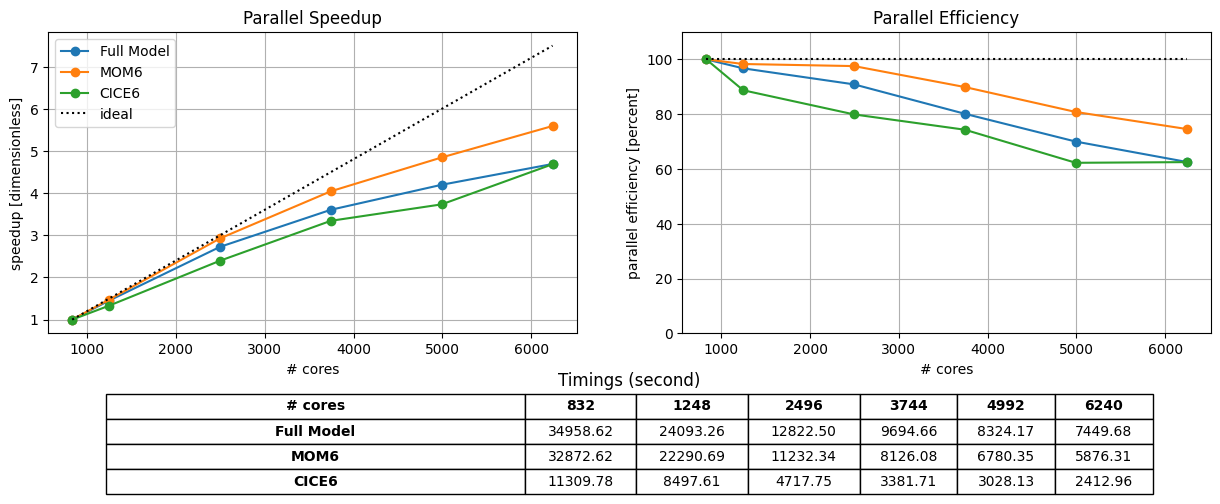

In [7]:
# Plot the scaling data, using only the best experiments
fig = om3_profiling.plot_scaling_data(
    components=["payu", "MOM6", "CICE6"],
    regions=[
        ["payu_model_run_duration_seconds"],
        ["Ocean"],
        ["Total"],
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean": "MOM6",
        "Total": "CICE6",
    },
    experiments=best_experiments,
    xlabel="# cores",
)

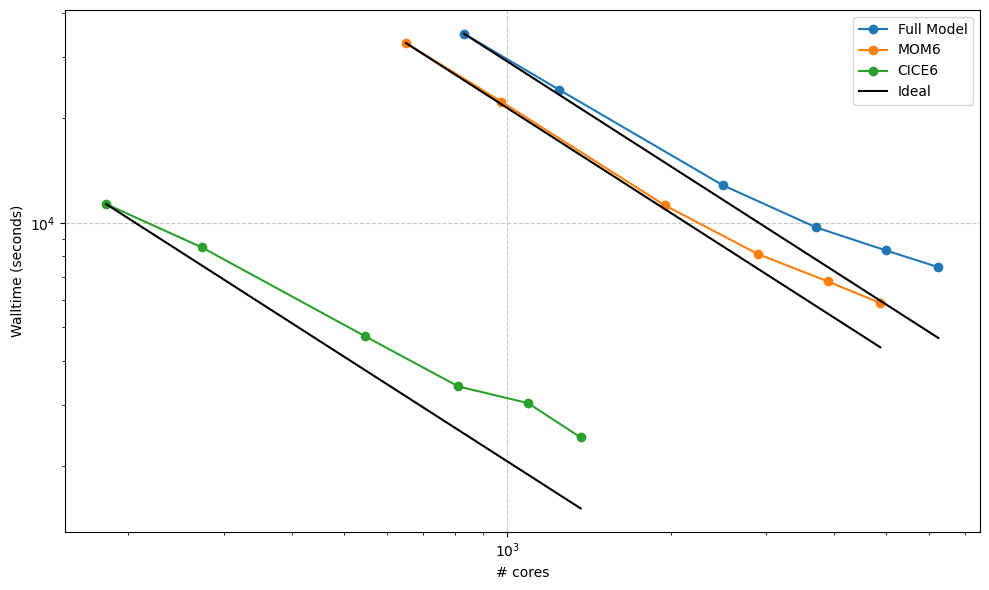

In [8]:
from access.profiling.manager import RegionGroup
fig2 = om3_profiling.plot_component_scaling_data(
    [
        RegionGroup("payu", ["payu_model_run_duration_seconds"], component="ACCESS-OM3 panan4km-iceshelf"),
        RegionGroup("MOM6", ["Ocean"], component="ocn"),
        RegionGroup("CICE6", ["Total"], component="ice"),
    ],
    metric=tmax,
    region_relabel_map={
        "payu_model_run_duration_seconds": "Full Model",
        "Ocean": "MOM6",
        "Total": "CICE6",
    },
    experiments=best_experiments,
    xlabel="# cores",
    ylabel="Walltime (seconds)",
)

## Analysis

## Summary


# Archive

Archive experiments.

In [9]:
om3_profiling.archive_experiments()

Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/panan4km-iceshelf/archive/om3-layout_panan4km-iceshelf_atm_546_cpl_546_ice_39x14_ocn_1950_rof_546.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/panan4km-iceshelf/archive/om3-layout_panan4km-iceshelf_atm_182_cpl_182_ice_26x7_ocn_650_rof_182.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/panan4km-iceshelf/archive/om3-layout_panan4km-iceshelf_atm_273_cpl_273_ice_39x7_ocn_975_rof_273.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/panan4km-iceshelf/archive/om3-layout_panan4km-iceshelf_atm_1365_cpl_1365_ice_65x21_ocn_4875_rof_1365.tar.gz is already archived. Skipping archiving.
Experiment at /g/data/tm70/model_scaling/ACCESS-rOM3/panan4km-iceshelf/archive/om3-layout_panan4km-iceshelf_atm_273_cpl_273_ice_21x13_ocn_975_rof_273.tar.gz is already archived. Skipping archiving.
Experim